In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
from keras.utils import load_img ,img_to_array 
import os
from random import randint
import pandas as pd
import pickle
import cv2

In [2]:
path = "pelak"
 
 
imagefiles = []


with os.scandir(path) as files:

    for file in files:
        if file.name.endswith('.jpg'):

            imagefiles.append(os.path.join(path,file.name) )

print(imagefiles)

['pelak\\pelak (1).jpg', 'pelak\\pelak (10).jpg', 'pelak\\pelak (11).jpg', 'pelak\\pelak (12).jpg', 'pelak\\pelak (13).jpg', 'pelak\\pelak (14).jpg', 'pelak\\pelak (15).jpg', 'pelak\\pelak (16).jpg', 'pelak\\pelak (17).jpg', 'pelak\\pelak (18).jpg', 'pelak\\pelak (19).jpg', 'pelak\\pelak (2).jpg', 'pelak\\pelak (20).jpg', 'pelak\\pelak (21).jpg', 'pelak\\pelak (22).jpg', 'pelak\\pelak (23).jpg', 'pelak\\pelak (24).jpg', 'pelak\\pelak (25).jpg', 'pelak\\pelak (26).jpg', 'pelak\\pelak (27).jpg', 'pelak\\pelak (28).jpg', 'pelak\\pelak (29).jpg', 'pelak\\pelak (3).jpg', 'pelak\\pelak (30).jpg', 'pelak\\pelak (31).jpg', 'pelak\\pelak (32).jpg', 'pelak\\pelak (33).jpg', 'pelak\\pelak (34).jpg', 'pelak\\pelak (35).jpg', 'pelak\\pelak (36).jpg', 'pelak\\pelak (37).jpg', 'pelak\\pelak (38).jpg', 'pelak\\pelak (39).jpg', 'pelak\\pelak (4).jpg', 'pelak\\pelak (40).jpg', 'pelak\\pelak (41).jpg', 'pelak\\pelak (42).jpg', 'pelak\\pelak (43).jpg', 'pelak\\pelak (44).jpg', 'pelak\\pelak (45).jpg', 'pe

In [3]:
def limg(file):
    # img = load_img(file, target_size=(100,100))
    img=cv2.imread(file)
    img=cv2.resize(img,(100,100))
    img=img.copy()
    img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # _,img=cv2.threshold(img,130,255,cv2.THRESH_BINARY)
    img = np.array(img) 
    return img

In [4]:
data=[]

for file in imagefiles:
    try:
        feat = limg(file)
        data.append(feat)
    except:
        print('error')

In [5]:
data=np.array(data)

In [6]:
data.shape

(87, 100, 100)

In [7]:

x_train=data
x_test=data

In [8]:
x_train_flattened = x_train.reshape((x_train.shape[0], -1))

x_train_flattened.shape

(87, 10000)

In [9]:


x_train_flattened = x_train.reshape((x_train.shape[0], -1))
x_test_flattened = x_test.reshape((x_test.shape[0], -1))

def build_autoencoder(input_dim, encoding_dim):
    input_img = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_img)
    encoded2 =Dense(1024, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='sigmoid')(encoded2) 

    autoencoder = Model(input_img, decoded)
    encoder = Model(input_img, encoded2)

    return autoencoder, encoder

input_dim = x_train_flattened.shape[1]

encoding_dim = 2048  


autoencoder, encoder = build_autoencoder(input_dim, encoding_dim)
autoencoder.compile(optimizer='adam', loss='mse')

print("OK")


OK


In [10]:
autoencoder.fit(
    x_train_flattened,
    x_train_flattened,
    epochs=20,
    batch_size=8 
)

encoded_features = encoder.predict(x_train_flattened)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - loss: 19159.0430
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - loss: 19145.1309
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - loss: 19142.5801
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - loss: 19141.2031
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - loss: 19140.0957
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 19139.1133
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - loss: 19138.3477
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 19137.6152
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - loss: 19136.9316
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 19136.4004
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - loss: 19135.8418
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - loss: 19135.3984
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - loss: 19135.1309
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 19134.8457
E

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(encoded_features)
labels = kmeans.labels_
print(labels)

[2 2 1 1 1 1 2 0 0 2 3 0 0 1 1 2 1 0 1 2 2 0 2 1 1 1 2 2 3 0 0 0 0 3 1 3 3
 0 1 1 1 1 0 1 3 0 0 1 1 0 3 1 2 2 1 3 0 0 0 0 3 3 0 0 2 3 3 0 3 2 0 1 0 3
 0 3 1 2 2 3 2 0 0 2 0 0 1]



Cluster 0 has 29 images.


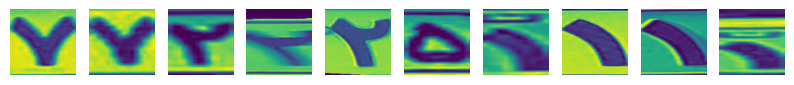


Cluster 1 has 24 images.


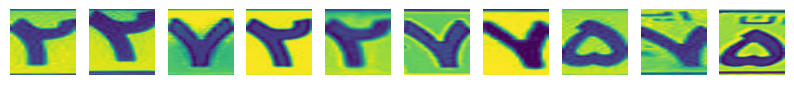


Cluster 2 has 18 images.


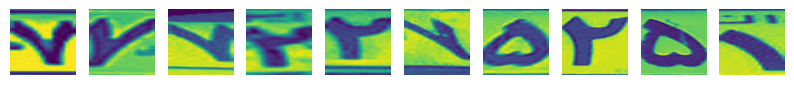


Cluster 3 has 16 images.


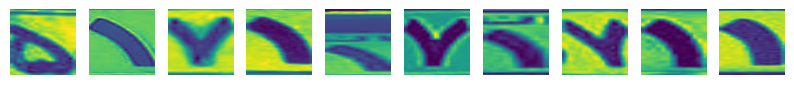


Cluster 4 has 0 images.


<Figure size 1000x200 with 0 Axes>


Cluster 5 has 0 images.


<Figure size 1000x200 with 0 Axes>


Cluster 6 has 0 images.


...

<Figure size 1000x200 with 0 Axes>


Cluster 8 has 0 images.


<Figure size 1000x200 with 0 Axes>


Cluster 9 has 0 images.


<Figure size 1000x200 with 0 Axes>

In [12]:
for i in range(10):
    cluster = np.where(labels == i)[0]
    print(f"\nCluster {i} has {len(cluster)} images.")
    plt.figure(figsize=(10, 2))
    for j, img_idx in enumerate(cluster[:10]):
        plt.subplot(1, 10, j + 1)
        plt.imshow(x_train[img_idx])
        plt.axis('off')
    plt.show()

In [35]:
from keras.utils import load_img 
from keras.utils import img_to_array 
from keras.applications.vgg16 import preprocess_input 

# models 
from keras.applications.vgg16 import VGG16 
from keras.models import Model

# clustering and dimension reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# for everything else
import os
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import pandas as pd
import pickle


In [20]:
model = VGG16(weights=None)  # بدون دانلود وزنه
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

def extract_features(file, model):
    img=cv2.imread(file)
    img=cv2.resize(img,(224,224))
    img=img.copy()
    img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,img=cv2.threshold(img,100,255,cv2.THRESH_BINARY)
    img = cv2.merge([img, img, img])
    reshaped_img = img.reshape(1,224,224,3) 
    imgx = preprocess_input(reshaped_img)
    features = model.predict(imgx)
    return features
   
data = {}


for img2 in imagefiles:

    feat = extract_features(img2,model)
    # print(feat)
    data[img2] = feat

          
 
# get a list of the filenames
filenames = np.array(list(data.keys()))

# get a list of just the features
feat = np.array(list(data.values()))

# reshape so that there are 210 samples of 4096 vectors
feat = feat.reshape(-1,4096)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [21]:
feat

array([[0.09921212, 0.        , 0.44226632, ..., 0.7815379 , 0.        ,
        0.6362425 ],
       [0.        , 0.00506949, 0.50420743, ..., 0.57734877, 0.14339659,
        0.59206045],
       [0.14226437, 0.        , 0.57357544, ..., 0.64269304, 0.0068288 ,
        0.7412209 ],
       ...,
       [0.01556971, 0.        , 0.5622814 , ..., 0.7629775 , 0.16570584,
        0.56093913],
       [0.01756466, 0.        , 0.5760377 , ..., 0.6950955 , 0.20805621,
        0.6308833 ],
       [0.0308257 , 0.        , 0.68092936, ..., 0.74539095, 0.09026489,
        0.6889357 ]], shape=(87, 4096), dtype=float32)

In [22]:

pca = PCA(n_components=80, random_state=22)
pca.fit(feat)
x = pca.transform(feat)

# cluster feature vectors
kmeans = KMeans(n_clusters=10, random_state=22)
kmeans.fit(x)
labels=kmeans.labels_

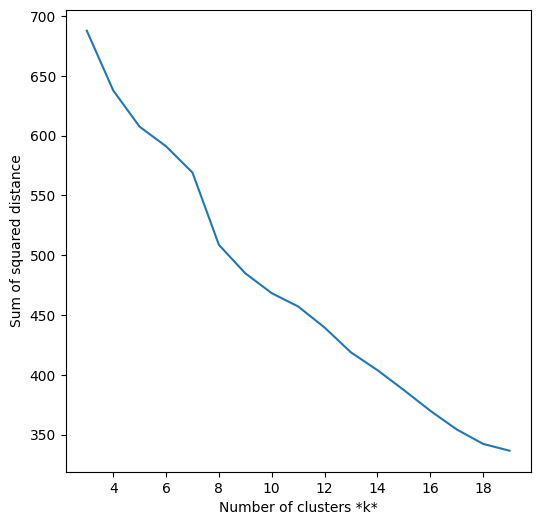

In [23]:

# holds the cluster id and the images { id: [images] }
groups = {}
for file, cluster in zip(filenames,kmeans.labels_):
    if cluster not in groups.keys():
        groups[cluster] = []
        groups[cluster].append(file)
    else:
        groups[cluster].append(file)

# function that lets you view a cluster (based on identifier)        
def view_cluster(cluster):
    plt.figure(figsize = (25,25))
    # gets the list of filenames for a cluster
    files = groups[cluster]
    # only allow up to 30 images to be shown at a time
    if len(files) > 30:
        print(f"Clipping cluster size from {len(files)} to 30")
        files = files[:29]
    # plot each image in the cluster
    for index, file in enumerate(files):
        plt.subplot(10,10,index+1)
        img = load_img(file)
        img = np.array(img)
        plt.imshow(img)
        plt.axis('off')
        
   
# this is just incase you want to see which value for k might be the best 
sse = []
list_k = list(range(3, 20))

for k in list_k:
    km = KMeans(n_clusters=k, random_state=22)
    km.fit(x)
    
    sse.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(6, 6))
plt.plot(list_k, sse)
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance');


Cluster 0 has 12 images.


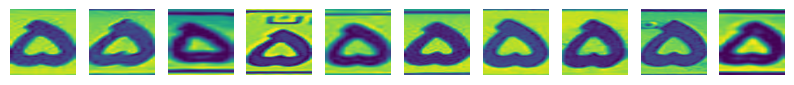


Cluster 1 has 14 images.


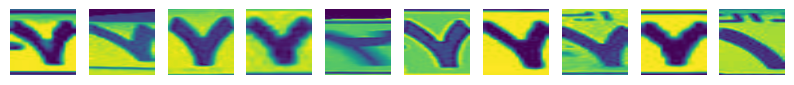


Cluster 2 has 16 images.


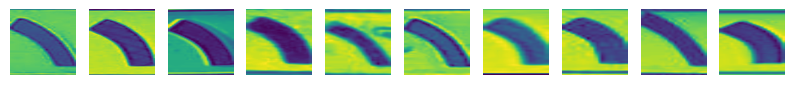


Cluster 3 has 7 images.


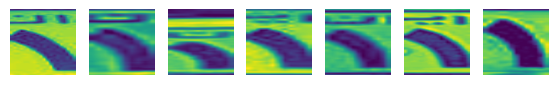


Cluster 4 has 18 images.


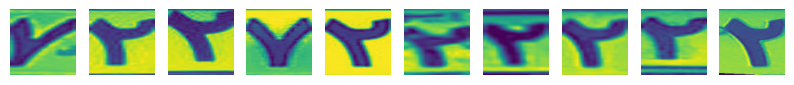


Cluster 5 has 5 images.


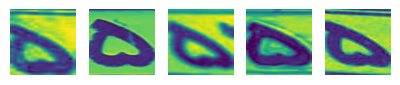


Cluster 6 has 9 images.


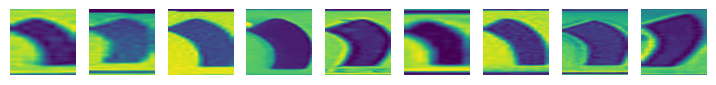


Cluster 7 has 2 images.


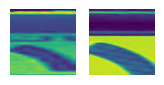


Cluster 8 has 2 images.


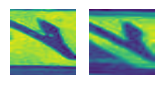


Cluster 9 has 2 images.


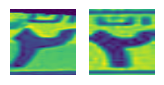

In [24]:
for i in range(10):
    cluster = np.where(labels == i)[0]
    print(f"\nCluster {i} has {len(cluster)} images.")
    plt.figure(figsize=(10, 2))
    for j, img_idx in enumerate(cluster[:10]):
        plt.subplot(1, 10, j + 1)
        plt.imshow(x_train[img_idx])
        plt.axis('off')
    plt.show()

In [29]:
import os
path = "image"
os.makedirs(path, exist_ok=True)  # ایجاد پوشه

path = "image"
 
 
imagefiles = []


with os.scandir(path) as files:

    for file in files:
        if file.name.endswith('.jpg'):

            imagefiles.append(os.path.join(path,file.name) )

print(imagefiles)

[]


In [30]:
  
model = VGG16(weights=None)  # بدون دانلود وزنه
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

def extract_features(file, model):
    img=load_img(file, target_size=(224,224)) 
    img = np.array(img) 
    reshaped_img = img.reshape(1,224,224,3) 
    imgx = preprocess_input(reshaped_img)
    features = model.predict(imgx)
    return features
   
data = {}


for img2 in imagefiles:

    feat = extract_features(img2,model)
    # print(feat)
    data[img2] = feat

          
 
# get a list of the filenames
filenames = np.array(list(data.keys()))

# get a list of just the features
feat = np.array(list(data.values()))

# reshape so that there are 210 samples of 4096 vectors
feat = feat.reshape(-1,4096)


In [ ]:

pca = PCA(n_components=40, random_state=22)
pca.fit(feat)
x = pca.transform(feat)

# cluster feature vectors
kmeans = KMeans(n_clusters=10, random_state=22)
kmeans.fit(x)
labels=kmeans.labels_

In [218]:
data=[]

def limg(file):
    # img = load_img(file, target_size=(100,100))
    img=load_img(file, target_size=(224,224)) 
    img = np.array(img) 
    return img

for file in imagefiles:
    try:
        feat2 = limg(file)
        data.append(feat2)
    except:
        print('error')

In [ ]:
for i in range(10):
    cluster = np.where(labels == i)[0]
    print(f"\nCluster {i} has {len(cluster)} images.")
    plt.figure(figsize=(10, 2))
    for j, img_idx in enumerate(cluster[:10]):
        plt.subplot(1, 10, j + 1)
        plt.imshow(data[img_idx])
        plt.axis('off')
    plt.show()